# 🟡 Chapter 4: Representing Data and Engineering Features
**Referensi:** *Introduction to Machine Learning with Python* (Andreas C. Müller & Sarah Guido)
---
> **Author:** Dhafi Dzakwan Pratama | 101032300213
> **Topik:** One-Hot Encoding, Binning, Polynomial Features, dan Automatic Feature Selection
---
## 1. Feature Engineering
Bagaimana kita merepresentasikan data adalah salah satu faktor penentu kesuksesan model *Machine Learning*. Proses menciptakan fitur baru atau mengubah bentuk fitur disebut **Feature Engineering**. Fitur yang tepat bisa membuat algoritma sederhana mengalahkan algoritma kompleks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline

## 2. Categorical Variables: One-Hot-Encoding
Banyak algoritma tidak bisa memproses data berupa teks/kategori secara langsung. Kita harus mengubahnya menjadi angka. Metode paling umum adalah *One-Hot-Encoding* (atau *Dummy Variables*), yang membuat kolom biner baru untuk setiap kategori.

In [2]:
# Membuat dataset dummy
data = {'Nama': ['Dhafi', 'Budi', 'Siti', 'Andi'],
        'Pekerjaan': ['Mahasiswa', 'Programmer', 'Mahasiswa', 'Desainer'],
        'Umur': [21, 25, 20, 28]}
df = pd.DataFrame(data)

print("DataFrame Asli:")
display(df)

# Menggunakan pandas get_dummies
df_encoded = pd.get_dummies(df, columns=['Pekerjaan'])
print("\nDataFrame setelah One-Hot-Encoding:")
display(df_encoded)

DataFrame Asli:


,Nama,Pekerjaan,Umur
0,Dhafi,Mahasiswa,21
1,Budi,Programmer,25
2,Siti,Mahasiswa,20
3,Andi,Desainer,28



DataFrame setelah One-Hot-Encoding:


,Nama,Umur,Pekerjaan_Desainer,Pekerjaan_Mahasiswa,Pekerjaan_Programmer
0,Dhafi,21,False,True,False
1,Budi,25,False,False,True
2,Siti,20,False,True,False
3,Andi,28,True,False,False


## 3. Interaksi dan Polynomial Features
Terkadang, fitur tunggal tidak cukup untuk memodelkan hubungan yang kompleks (terutama untuk model linier). Menambahkan fitur *Polynomial* (kuadrat, pangkat tiga, dll) dapat membuat model linier mampu menyesuaikan diri dengan data yang melengkung.

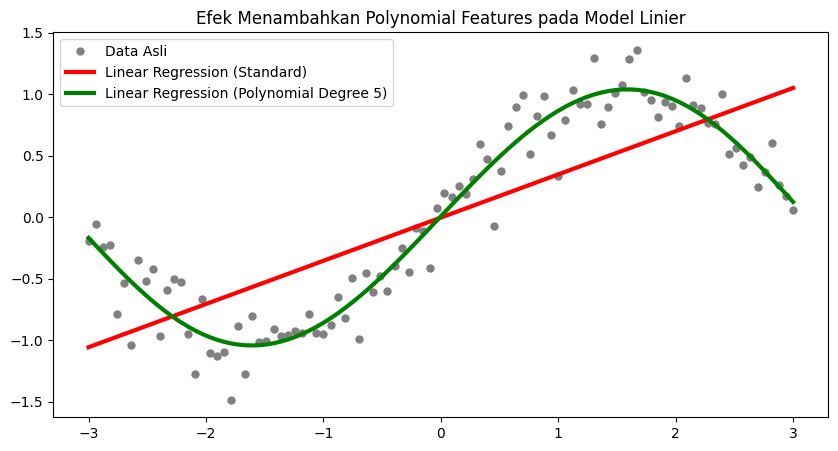

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Membuat data non-linier (gelombang sinus dengan sedikit noise)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(X[:, 0]) + np.random.normal(0, 0.2, X.shape[0])

# Model Linier standar (Underfitting)
reg = LinearRegression().fit(X, y)
y_pred_linear = reg.predict(X)

# Menambahkan Polynomial Features pangkat 5
poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(X)

# Model Linier setelah data dipolynomial-kan
reg_poly = LinearRegression().fit(X_poly, y)
y_pred_poly = reg_poly.predict(X_poly)

# Visualisasi
plt.figure(figsize=(10, 5))
plt.plot(X, y, 'o', c='gray', markersize=5, label='Data Asli')
plt.plot(X, y_pred_linear, c='red', lw=3, label='Linear Regression (Standard)')
plt.plot(X, y_pred_poly, c='green', lw=3, label='Linear Regression (Polynomial Degree 5)')
plt.title("Efek Menambahkan Polynomial Features pada Model Linier")
plt.legend();

## 4. Automatic Feature Selection
Ketika kita memiliki terlalu banyak fitur (terutama setelah menambahkan polinomial), kita perlu membuang fitur yang tidak berguna agar model tidak overfitting dan lebih cepat. Buku ini mencontohkan seleksi fitur univariat (seperti ANOVA).

Bentuk data sebelum feature selection: (569, 80)
Bentuk data setelah feature selection: (569, 40)



Text(0, -0.6, 'Catatan: Sebagian besar fitur asli (index 0-29) dipilih, sedangkan noise dibuang.')

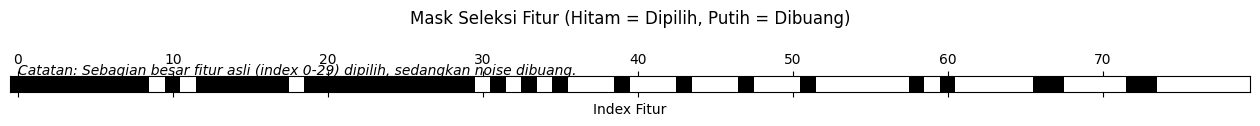

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile, f_classif

cancer = load_breast_cancer()

# Simulasi: Menambahkan 50 fitur acak (noise/sampah) ke dataset asli
rng = np.random.RandomState(42)
noise = rng.normal(size=(len(cancer.data), 50))
X_w_noise = np.hstack([cancer.data, noise])

# Menggunakan SelectPercentile untuk memilih 50% fitur terbaik
select = SelectPercentile(score_func=f_classif, percentile=50)
select.fit(X_w_noise, cancer.target)
X_selected = select.transform(X_w_noise)

print(f"Bentuk data sebelum feature selection: {X_w_noise.shape}")
print(f"Bentuk data setelah feature selection: {X_selected.shape}\n")

# Visualisasi fitur mana saja yang dipilih
mask = select.get_support()
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Index Fitur")
plt.yticks(())
plt.title("Mask Seleksi Fitur (Hitam = Dipilih, Putih = Dibuang)\n");
plt.text(0, -0.6, "Catatan: Sebagian besar fitur asli (index 0-29) dipilih, sedangkan noise dibuang.",
         fontsize=10, style='italic')